# Deep Neural Network in Keras

In this notebook, we improve on our [intermediate neural net](https://github.com/the-deep-learners/deep-learning-illustrated/blob/master/notebooks/intermediate_net_in_keras.ipynb) by applying the theory we've covered since.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/the-deep-learners/deep-learning-illustrated/blob/master/notebooks/deep_net_in_keras.ipynb)

#### Load dependencies

In [6]:
# import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical

#### Load data

In [3]:
(X_train, y_train), (X_valid, y_valid) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### Preprocess data

In [4]:
X_train = X_train.reshape(60000, 784).astype('float32')/255
X_valid = X_valid.reshape(10000, 784).astype('float32')/255

In [ ]:
# X_train /= 255
# X_valid /= 255

In [5]:
n_classes = 10
y_train = to_categorical(y_train, n_classes)
y_valid = to_categorical(y_valid, n_classes)

#### Design neural network architecture

In [7]:
model = Sequential([Input(shape=(784,)),
                    Dense(64, activation='relu'),
                    BatchNormalization(),

                    Dense(64, activation='relu'),
                    BatchNormalization(),

                    Dense(64, activation='relu'),
                    BatchNormalization(),
                    Dropout(0.2),

                    Dense(10, activation='softmax')]
)

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,978 (234.29 KB)

 Trainable params: 59,594 (232.79 KB)

 Non-trainable params: 384 (1.50 KB)

#### Configure model

In [9]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

#### Train!

In [10]:
history = model.fit(X_train, y_train,
                    batch_size=128,
                    epochs=20,
                    verbose=1,
                    validation_data=(X_valid, y_valid)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8860 - loss: 0.3796 - val_accuracy: 0.9503 - val_loss: 0.1577
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9543 - loss: 0.1517 - val_accuracy: 0.9622 - val_loss: 0.1205
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9656 - loss: 0.1136 - val_accuracy: 0.9683 - val_loss: 0.1037
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9716 - loss: 0.0910 - val_accuracy: 0.9695 - val_loss: 0.0952
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9758 - loss: 0.0780 - val_accuracy: 0.9704 - val_loss: 0.0974
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9784 - loss: 0.0676 - val_accuracy: 0.9722 - val_loss: 0.0950
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9804 - loss: 0.0606 - val_accuracy: 0.9726 - val_loss: 0.0996
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9835 - loss: 0.0520 - val_accuracy: 0.

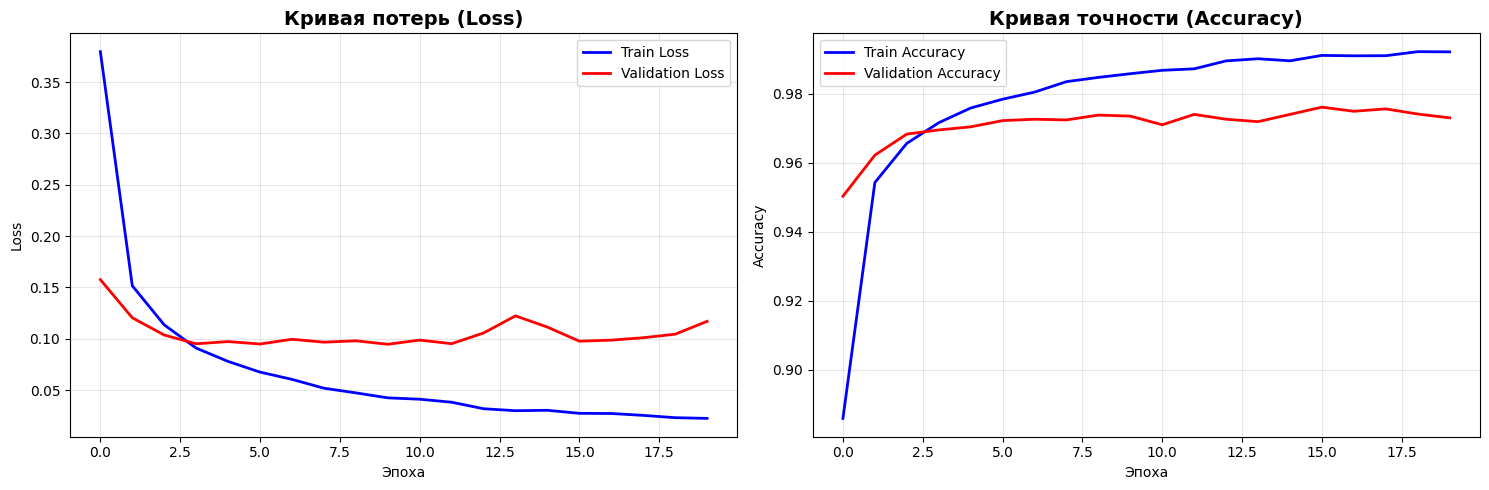


Лучшие результаты на эпохе 10:
  Train Loss: 0.0947
  Val Loss: 0.0947
  Train Accuracy: 0.9761
  Val Accuracy: 0.9761


In [11]:
import matplotlib.pyplot as plt

# Создаем графики в две колонки
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График 1: Кривая потерь (loss)
ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
ax1.set_title('Кривая потерь (Loss)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Кривая точности (accuracy)
ax2.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
ax2.set_title('Кривая точности (Accuracy)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Дополнительно: выводим лучшие результаты
best_epoch = history.history['val_loss'].index(min(history.history['val_loss'])) + 1
print(f"\nЛучшие результаты на эпохе {best_epoch}:")
print(f"  Train Loss: {min(history.history['val_loss']):.4f}")
print(f"  Val Loss: {min(history.history['val_loss']):.4f}")
print(f"  Train Accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"  Val Accuracy: {max(history.history['val_accuracy']):.4f}")